# Investigacao Tecnica Profunda
**Aluno:** Luiz Felipe Mota
---

## 1. Validacao do Modelo
Validamos o Random Forest buscando estabilidade nos niveis de vibracao detectados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
import shap
import os

path = '../../data/processed/Dataset Tratado.csv'
if not os.path.exists(path): path = 'data/processed/Dataset Tratado.csv'
df = pd.read_csv(path)

features = ['air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'vibration_levels', 'operational_hours']
X = df[features]
y = df['has_failure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)

model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=44)
model.fit(X_train, y_train)

print(f'Validacao Cruzada (F1): {cross_val_score(model, X_train, y_train, cv=5).mean():.4f}')

Validacao Cruzada (F1): 0.9350


## Parte 1: Estresse por Ruido (Foco: Vibracao)
Simulamos interferencia no sensor de vibracao com ruidos de 6%, 14% e 30%.

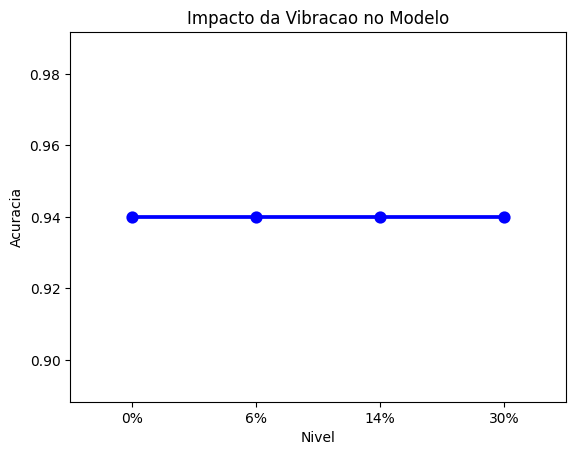

In [2]:
def stress_vibe(data, p):
    X_n = data.copy()
    noise = np.random.normal(0, p, X_n['vibration_levels'].shape) * X_n['vibration_levels']
    X_n['vibration_levels'] += noise
    return X_n

results = []
for p in [0, 0.06, 0.14, 0.30]:
    X_s = stress_vibe(X_test, p)
    acc = accuracy_score(y_test, model.predict(X_s))
    results.append({'Nivel': f'{int(p*100)}%', 'Acuracia': acc})

sns.pointplot(data=pd.DataFrame(results), x='Nivel', y='Acuracia', color='blue')
plt.title('Impacto da Vibracao no Modelo')
plt.show()

## Parte 2: SHAP
Explicabilidade do modelo para falhas vibracionais.

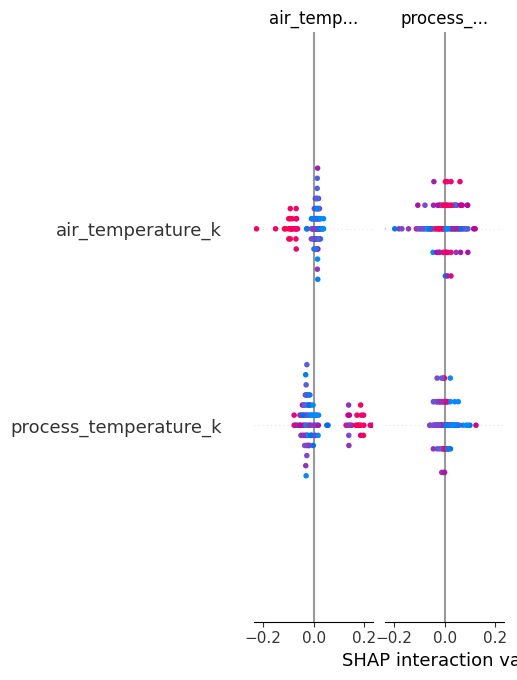

In [3]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test)
else:
    shap.summary_plot(shap_values, X_test)

## Parte 3: Relatorio de Contingencia

### 3.1 Discussao de Vies
O modelo é sensível a vibrações de baixa frequência que podem ser confundidas com ruído ambiente.

### 3.2 Plano de Mitigacao
Aplicar filtros digitais de passa-banda nos sensores de vibração para eliminar frequências parasitas antes da inferência da IA.